In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder




from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier

from sklearn import metrics
from sklearn.metrics import confusion_matrix, roc_auc_score, precision_recall_curve, classification_report,recall_score
from sklearn import tree

from sklearn.model_selection import GridSearchCV


import warnings
warnings.filterwarnings("ignore")





## Load the dataset and pre-process

In [105]:
# Loading the dataset
df = pd.read_csv('out_data/uniquely_classified.csv')
df.head()

,name,agg_master_class,master_class,detection_count,QSO,AGN,Seyfert_1,Seyfert_2,HMXB,LMXB,...,hard_ms,powlaw_gamma,bb_kt,var_prob_b,var_ratio_b,var_prob_h,var_ratio_h,var_prob_s,var_ratio_s,var_newq_b
0,2CXO J004231.1+411621,XB,HMXB,97.0,0.056±0.152,0.156±0.209,0.079±0.151,0.04±0.106,0.241±0.215,0.213±0.228,...,-0.166146,1.680010,0.655169,5.262590e-02,6.911782e-05,9.448859e-02,1.152777e-03,0.106866,0.005875,1.000000
1,2CXO J004248.5+411521,XB,HMXB,93.0,0.039±0.107,0.113±0.175,0.121±0.174,0.091±0.193,0.274±0.254,0.159±0.185,...,-0.082448,1.336010,0.840470,7.789449e-02,7.501341e-03,9.672048e-02,2.150152e-03,0.111110,0.012999,1.002214
2,2CXO J123049.3+122328,Seyfert,Seyfert_1,85.0,0.113±0.249,0.138±0.241,0.467±0.397,0.102±0.251,0.021±0.106,0.017±0.115,...,-0.002498,0.267213,1.485400,2.214157e-09,1.405095e-11,1.356018e-08,1.512448e-10,0.046467,0.000742,1.000000
3,2CXO J004254.9+411603,XB,HMXB,84.0,0.053±0.165,0.096±0.147,0.065±0.119,0.093±0.219,0.309±0.256,0.179±0.186,...,-0.108682,1.970800,0.629937,6.387722e-02,2.748553e-04,1.225383e-01,1.181259e-02,0.072829,0.001133,1.000000
4,2CXO J004232.0+411314,XB,HMXB,80.0,0.014±0.081,0.059±0.142,0.153±0.262,0.257±0.348,0.335±0.367,0.094±0.192,...,-0.387258,1.362590,0.681531,7.153673e-02,5.506967e-03,1.064423e-01,1.384354e-02,0.068320,0.001912,1.001241


In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8271 entries, 0 to 8270
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              8271 non-null   object 
 1   agg_master_class  8271 non-null   object 
 2   master_class      8271 non-null   object 
 3   detection_count   8271 non-null   float64
 4   QSO               8271 non-null   object 
 5   AGN               8271 non-null   object 
 6   Seyfert_1         8271 non-null   object 
 7   Seyfert_2         8271 non-null   object 
 8   HMXB              8271 non-null   object 
 9   LMXB              8271 non-null   object 
 10  XB                8271 non-null   object 
 11  YSO               8271 non-null   object 
 12  TTau*             8271 non-null   object 
 13  Orion_V*          8271 non-null   object 
 14  ra                8271 non-null   float64
 15  dec               8271 non-null   float64
 16  hard_hm           8271 non-null   float64


In [107]:
df.agg_master_class.unique()

array(['XB', 'Seyfert', 'YSO', 'AGN'], dtype=object)

In [131]:
df['agg_master_class'].value_counts(normalize=True) * 100

agg_master_class
XB         30.528352
AGN        28.073993
YSO        27.602466
Seyfert    13.795188
Name: proportion, dtype: float64

### Observations:
- There are 8271 sources and 28 columns in the dataset.
- All the columns have 8271 non-null values, thus no missing data.
- The dataset is nearly balanced, though Seyfert has only 13%.

### dummy variables for categorical variables

In [108]:
#dict_OverTime = {'QSO': 0, 'AGN':1, 'Seyfert_1':2, 'Seyfert_2':3}
# to_get_dummies_for = ['master_class']
# df = pd.get_dummies(data = df, columns = to_get_dummies_for, drop_first = True) 
# df.head()

le = LabelEncoder()
y = le.fit_transform(df['agg_master_class'])


### To train the dataset, let's drop the agg_master_class and master_class as they are targets.


In [109]:
Y = le.fit_transform(df['agg_master_class'])
#Y = df.agg_master_class
X = df.drop(columns=['name', 'agg_master_class', 'master_class',\
                     'QSO','AGN','Seyfert_1','Seyfert_2','HMXB', \
                     'LMXB','XB','YSO','TTau*','Orion_V*', 'ra', 'dec'])


### Creating metric function 

In [110]:
def metrics_score(actual, predicted):
    # 1️⃣ Print classification report
    print(classification_report(actual, predicted))
    
    # 2️⃣ Confusion matrix
    cm = confusion_matrix(actual, predicted)
    
    # 3️⃣ Plot heatmap
    plt.figure(figsize=(7,6))
    class_labels = [0, 1, 2, 3]   # or replace with your actual class names if you have them
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels)
    
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


### Splitting the data into 70% train and 30% test set

In [111]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.3, random_state = 1, stratify=Y)

## Building Models

### Decision Tree model

In [112]:
dt = DecisionTreeClassifier(class_weight = {0: 0.17, 1: 0.83}, random_state = 1)

In [113]:
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,"{0: 0.17, 1: 0.83}"


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1625
           1       1.00      1.00      1.00       799
           2       1.00      1.00      1.00      1767
           3       1.00      1.00      1.00      1598

    accuracy                           1.00      5789
   macro avg       1.00      1.00      1.00      5789
weighted avg       1.00      1.00      1.00      5789



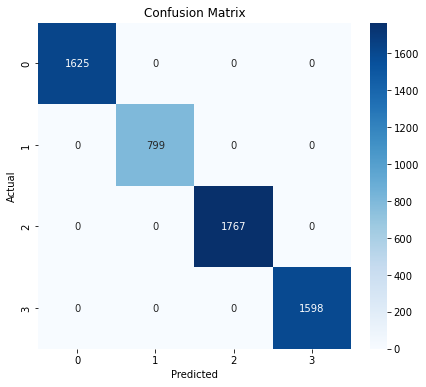

In [55]:
# Checking performance on the training dataset
y_train_pred_dt = dt.predict(X_train)

metrics_score(y_train, y_train_pred_dt)

              precision    recall  f1-score   support

           0       0.65      0.69      0.67       697
           1       0.50      0.51      0.51       342
           2       0.69      0.67      0.68       758
           3       0.80      0.78      0.79       685

    accuracy                           0.68      2482
   macro avg       0.66      0.66      0.66      2482
weighted avg       0.69      0.68      0.68      2482



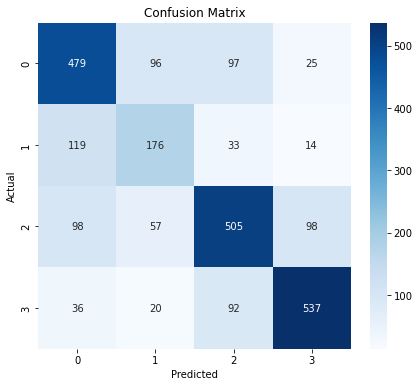

In [56]:
# Checking performance on the test dataset
y_test_pred_dt = dt.predict(X_test)

metrics_score(y_test, y_test_pred_dt)

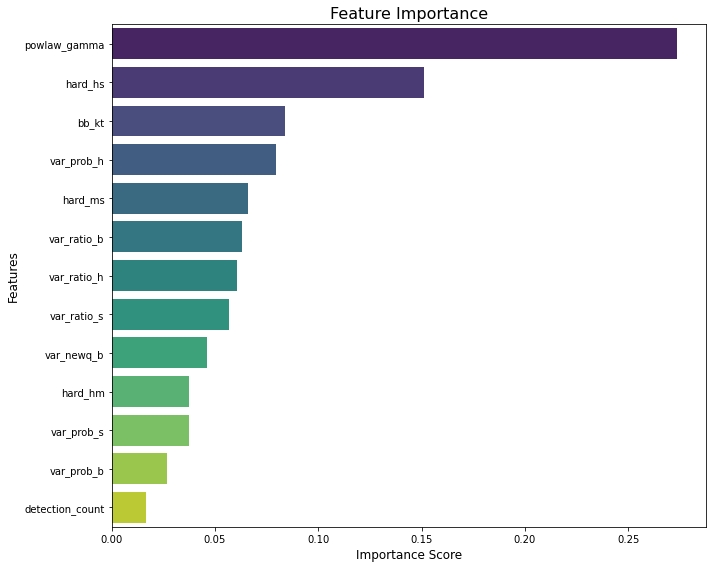

In [57]:
# 📊 Plot Feature Importance (clean & robust version)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get feature importances from the trained model
importances = dt.feature_importances_
columns = X.columns

# Build DataFrame and sort
importance_df = (
    pd.DataFrame({'Feature': columns, 'Importance': importances})
      .sort_values(by='Importance', ascending=False)
)

# Plot
plt.figure(figsize=(10, 8))
sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature',
    palette='viridis'
)

plt.title('Feature Importance', fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()


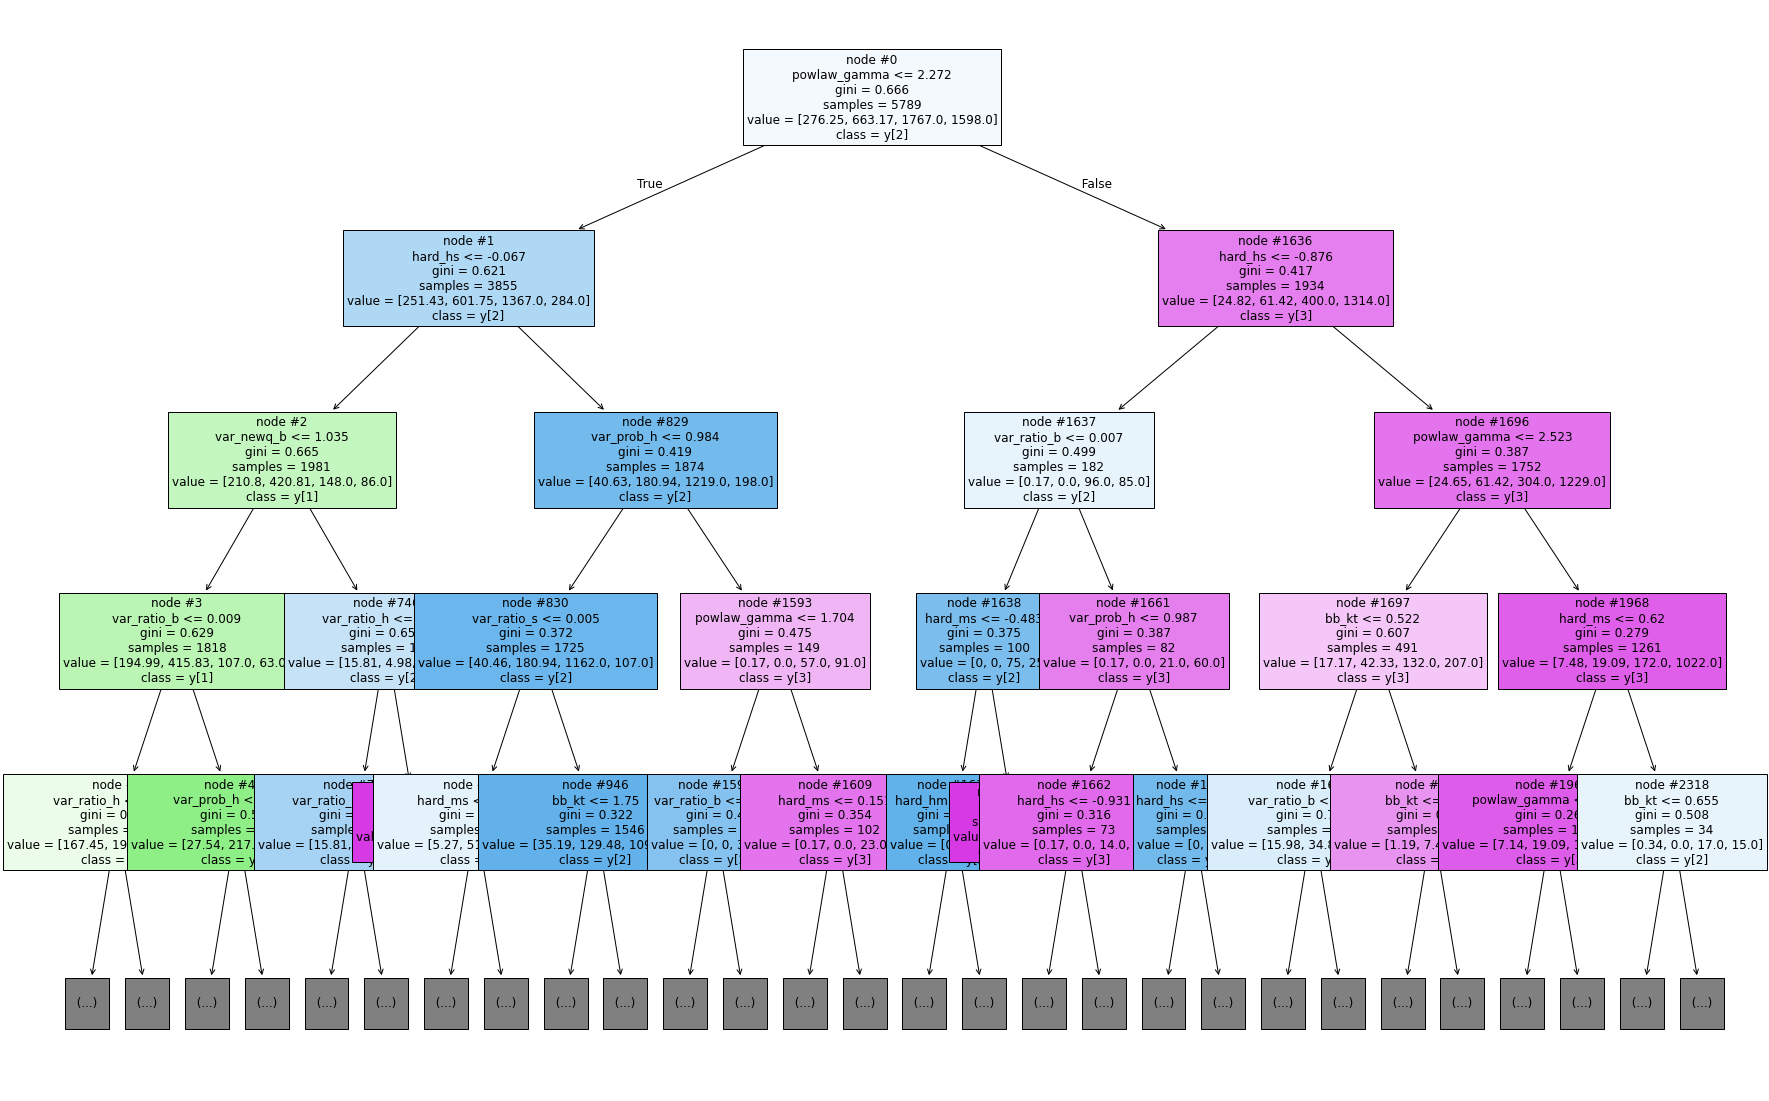

In [44]:
features = list(X.columns)

plt.figure(figsize = (30, 20))

tree.plot_tree(dt, max_depth = 4, feature_names = features, filled = True, fontsize = 12, node_ids = True, class_names = True)

plt.show()


### Random Forest model

In [92]:
# Fitting the Random Forest classifier on the training data
rf_estimator = RandomForestClassifier(class_weight = {0: 0.17, 1: 0.83}, random_state = 1)

rf_estimator.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


              precision    recall  f1-score   support

           0      1.000     1.000     1.000      1625
           1      1.000     1.000     1.000       799
           2      1.000     1.000     1.000      1767
           3      1.000     1.000     1.000      1598

    accuracy                          1.000      5789
   macro avg      1.000     1.000     1.000      5789
weighted avg      1.000     1.000     1.000      5789



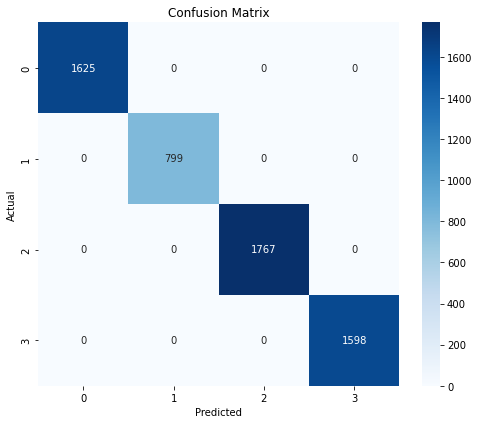

Skipping ROC/AUC: 'proba' (predict_proba or decision_function output) not provided.


In [94]:
# Checking performance on the training data
y_pred_train_rf = rf_estimator.predict(X_train)

metrics_score(y_train, y_pred_train_rf)

              precision    recall  f1-score   support

           0      0.712     0.844     0.772       697
           1      0.754     0.465     0.575       342
           2      0.755     0.734     0.744       758
           3      0.829     0.858     0.844       685

    accuracy                          0.762      2482
   macro avg      0.763     0.725     0.734      2482
weighted avg      0.763     0.762     0.756      2482



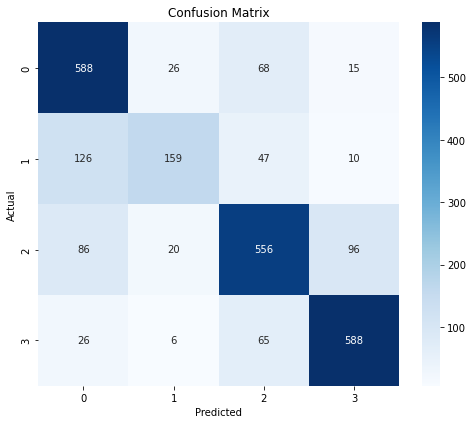

Skipping ROC/AUC: 'proba' (predict_proba or decision_function output) not provided.


In [95]:
# Checking performance on the testing data
y_pred_test_rf = rf_estimator.predict(X_test)

metrics_score(y_test, y_pred_test_rf)

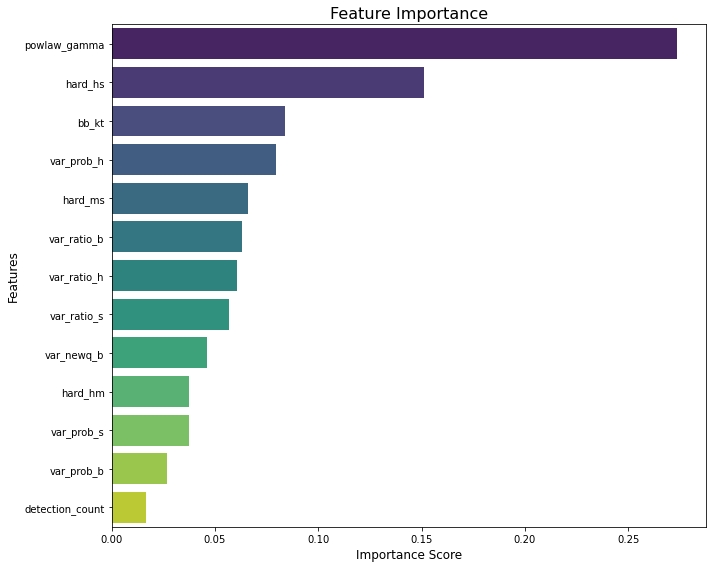

In [96]:
# 📊 Plot Feature Importance (clean & robust version)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get feature importances from the trained model
importances = dt.feature_importances_
columns = X.columns

# Build DataFrame and sort
importance_df = (
    pd.DataFrame({'Feature': columns, 'Importance': importances})
      .sort_values(by='Importance', ascending=False)
)

# Plot
plt.figure(figsize=(10, 8))
sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature',
    palette='viridis'
)

plt.title('Feature Importance', fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

#### random forest finetuning

In [98]:

params = {
    'criterion': ['gini', 'entropy'],
    'min_samples_leaf': [1, 3, 5],
    'n_estimators': [100, 300, 500]
}
grid = GridSearchCV(rf_estimator, params, scoring='f1_macro', cv=5)  ### cv: cross-validation 5-fold 
grid.fit(X, y)

,estimator,RandomForestC...andom_state=1)
,param_grid,"{'criterion': ['gini', 'entropy'], 'min_samples_leaf': [1, 3, ...], 'n_estimators': [100, 300, ...]}"
,scoring,'f1_macro'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,300


In [99]:
# Set the classifier to the best combination of parameters
rf_estimator = grid.best_estimator_

# Fit the best estimator to the data
rf_estimator.fit(X_train, y_train)

,n_estimators,300
,criterion,'entropy'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


              precision    recall  f1-score   support

           0      0.721     0.832     0.773       697
           1      0.735     0.494     0.591       342
           2      0.758     0.740     0.749       758
           3      0.835     0.863     0.849       685

    accuracy                          0.766      2482
   macro avg      0.762     0.732     0.740      2482
weighted avg      0.766     0.766     0.761      2482



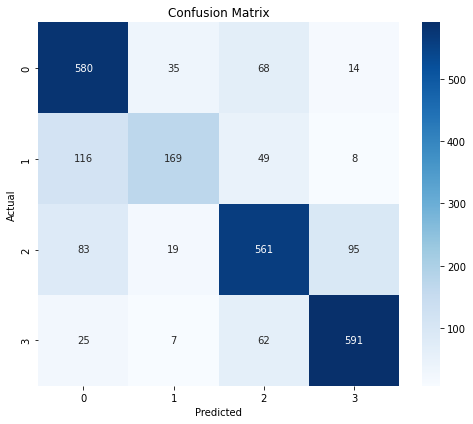

Skipping ROC/AUC: 'proba' (predict_proba or decision_function output) not provided.


In [100]:
y_pred_test_rf = rf_estimator.predict(X_test)

metrics_score(y_test, y_pred_test_rf)

### XGBoost model

In [73]:
import xgboost as xgb
xgb_model = xgb.XGBClassifier(
    max_depth=6,
    learning_rate=0.1,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8
)


In [74]:
xgb_model.fit(X_train, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


              precision    recall  f1-score   support

           0       0.75      0.82      0.79       697
           1       0.72      0.58      0.64       342
           2       0.76      0.76      0.76       758
           3       0.84      0.85      0.85       685

    accuracy                           0.78      2482
   macro avg       0.77      0.75      0.76      2482
weighted avg       0.78      0.78      0.78      2482



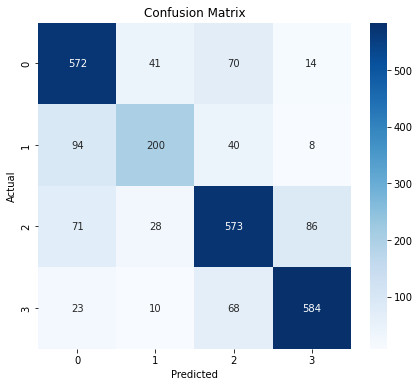

In [76]:
# Checking performance on the testing data
y_pred_test_xgb = xgb_model.predict(X_test)

metrics_score(y_test, y_pred_test_xgb)

In [78]:
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    RocCurveDisplay
)
from sklearn.preprocessing import label_binarize

def metrics_score(actual, predicted, proba=None, class_labels=None):
    """
    actual:        array-like, shape (n_samples,)
    predicted:     array-like, shape (n_samples,)
    proba:         array-like, shape (n_samples, n_classes) or (n_samples,), optional
                   Predicted probabilities (or decision_function scores).
                   Required for ROC/AUC plots & scores.
    class_labels:  list of class labels in order of columns of 'proba'.
                   If None, inferred from np.unique(actual) sorted.
    """
    actual = np.asarray(actual)
    predicted = np.asarray(predicted)

    # --- 1) Text report
    print(classification_report(actual, predicted, digits=3))

    # --- 2) Confusion matrix heatmap
    cm = confusion_matrix(actual, predicted)
    if class_labels is None:
        class_labels = np.unique(actual)
    plt.figure(figsize=(7,6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_labels, yticklabels=class_labels
    )
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    # --- 3) ROC–AUC (supports binary or multi-class, needs proba)
    if proba is None:
        print("Skipping ROC/AUC: 'proba' (predict_proba or decision_function output) not provided.")
        return

    proba = np.asarray(proba)

    # If binary and proba is (n_samples,), make it (n_samples, 2) for consistency
    unique_classes = np.unique(actual)
    n_classes = len(unique_classes)

    # Map actual to indices [0..n_classes-1] consistent with class_labels order
    if class_labels is None:
        class_labels = sorted(unique_classes.tolist())
    class_to_idx = {c: i for i, c in enumerate(class_labels)}
    y_indices = np.vectorize(class_to_idx.get)(actual)

    # Binarize true labels for ROC computation
    y_bin = label_binarize(y_indices, classes=list(range(len(class_labels))))

    # Handle binary shapes
    if n_classes == 2:
        # If proba is shape (n_samples,), interpret as positive class score
        if proba.ndim == 1:
            pos_scores = proba
        else:
            # Find index of positive class (assume the *second* class in class_labels is positive)
            pos_idx = 1 if proba.shape[1] == 2 else class_to_idx[class_labels[1]]
            pos_scores = proba[:, pos_idx]

        auc = roc_auc_score(y_bin, pos_scores)  # binary AUC
        print(f"ROC–AUC (binary): {auc:.4f}")

        # ROC curve
        RocCurveDisplay.from_predictions(y_bin, pos_scores)
        plt.title(f'ROC Curve (positive class: {class_labels[1]})')
        plt.tight_layout()
        plt.show()

    else:
        # --- Multi-class one-vs-rest
        if proba.ndim == 1:
            raise ValueError("For multi-class ROC, 'proba' must be 2D: shape (n_samples, n_classes).")

        # Ensure proba columns align with class_labels order
        if proba.shape[1] != len(class_labels):
            raise ValueError("proba.shape[1] must equal len(class_labels). Provide class_labels aligned with proba columns.")

        # Macro and micro ROC–AUC
        macro_auc = roc_auc_score(y_bin, proba, average='macro', multi_class='ovr')
        micro_auc = roc_auc_score(y_bin, proba, average='micro', multi_class='ovr')
        print(f"ROC–AUC (macro): {macro_auc:.4f}")
        print(f"ROC–AUC (micro): {micro_auc:.4f}")

        # Plot per-class ROC + micro-average
        plt.figure(figsize=(7,6))
        for i, cls in enumerate(class_labels):
            RocCurveDisplay.from_predictions(y_bin[:, i], proba[:, i], name=f"Class {cls}")
        # micro-average
        RocCurveDisplay.from_predictions(y_bin.ravel(), proba.ravel(), name="micro-average", color="black")
        plt.title('ROC Curves (One-vs-Rest)')
        plt.tight_layout()
        plt.show()


              precision    recall  f1-score   support

           0      0.753     0.821     0.785       697
           1      0.717     0.585     0.644       342
           2      0.763     0.756     0.759       758
           3      0.844     0.853     0.848       685

    accuracy                          0.777      2482
   macro avg      0.769     0.753     0.759      2482
weighted avg      0.776     0.777     0.775      2482



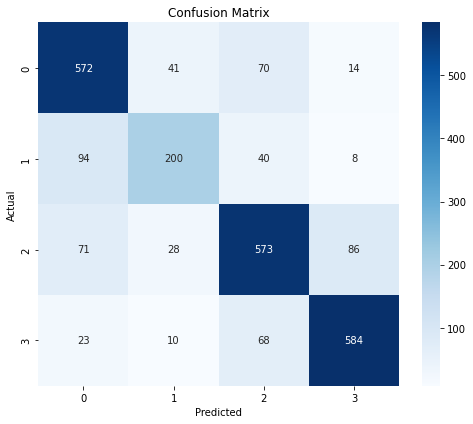

ROC–AUC (macro): 0.9401
ROC–AUC (micro): 0.9449


<Figure size 504x432 with 0 Axes>

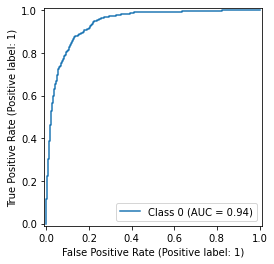

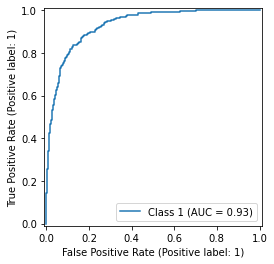

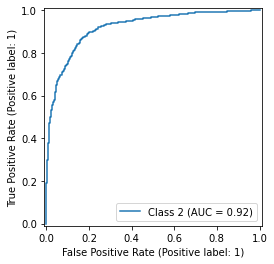

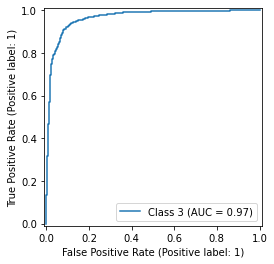

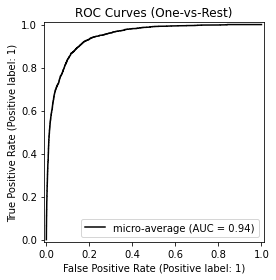

In [81]:
y_proba = xgb_model.predict_proba(X_test)
metrics_score(y_test,y_pred_test_xgb, proba=y_proba, class_labels=np.unique(y_test))


### finetune the threshold

In [101]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score

def plot_multiclass_pr(y_true, y_score, class_labels=None, title='PR Curves (One-vs-Rest)'):
    """
    y_true:  (n_samples,)  真值，多分类标签（可为数字或字符串）
    y_score: (n_samples, n_classes)  每一类的分数或概率（predict_proba 或 decision_function 的输出）
    class_labels: list or array，长度 = n_classes；若为 None，则用 np.unique(y_true) 的排序
    """
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    if y_score.ndim != 2:
        raise ValueError("y_score 必须是二维数组，形状为 (n_samples, n_classes)。")

    if class_labels is None:
        class_labels = np.unique(y_true)
    class_labels = np.array(class_labels)

    if y_score.shape[1] != len(class_labels):
        raise ValueError("y_score 的列数必须与 class_labels 的长度一致。")

    # 二值化真值用于 OvR
    y_bin = label_binarize(y_true, classes=class_labels)

    # 计算每类的 PR 曲线与 AP
    ap_per_class = {}
    plt.figure(figsize=(7, 6))
    for i, cls in enumerate(class_labels):
        precision, recall, _ = precision_recall_curve(y_bin[:, i], y_score[:, i])
        ap = average_precision_score(y_bin[:, i], y_score[:, i])
        ap_per_class[cls] = ap
        plt.plot(recall, precision, lw=1.8, label=f"{cls} (AP={ap:.3f})")

    # micro-average（把所有类别展平成一个二分类问题）
    precision_micro, recall_micro, _ = precision_recall_curve(y_bin.ravel(), y_score.ravel())
    ap_micro = average_precision_score(y_bin, y_score, average='micro')
    plt.plot(recall_micro, precision_micro, lw=2.2, linestyle='--', label=f"micro-average (AP={ap_micro:.3f})")

    # macro-average（对各类 AP 取算术平均；注意这不是“宏 PR 曲线”，而是宏 AP）
    ap_macro = average_precision_score(y_bin, y_score, average='macro')

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(title + f"\nmacro-AP={ap_macro:.3f}")
    plt.legend(loc='best')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return {"per_class_AP": ap_per_class, "micro_AP": ap_micro, "macro_AP": ap_macro}


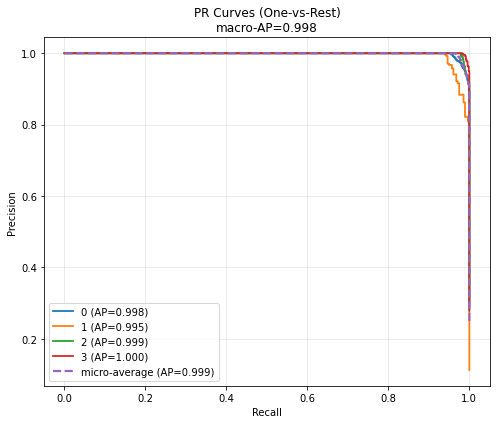

{'per_class_AP': {np.int64(0): 0.9984606816808278, np.int64(1): 0.9947575827981368, np.int64(2): 0.9991405208399555, np.int64(3): 0.9996892783109197}, 'micro_AP': 0.9987779029383448, 'macro_AP': 0.99801201590746}


In [102]:
# 以 XGBoost 为例（任意支持 predict_proba 的分类器都行）
# y_true: 测试集真值 (n_samples,)
# y_proba: clf.predict_proba(X_test) -> (n_samples, n_classes)

res = plot_multiclass_pr(y_pred_test_xgb, y_proba, class_labels=np.unique(y_test))
print(res)  # 查看 per-class AP, micro_AP, macro_AP


### lightGBM model

In [126]:
from lightgbm import LGBMClassifier
from lightgbm import LGBMClassifier, early_stopping, log_evaluation

lgbm_model = LGBMClassifier(
    n_estimators=2000,        # use early stopping to pick best_iteration_
    learning_rate=0.03,
    num_leaves=31,            # increase for more complexity, but watch overfitting
    max_depth=-1,             # no hard limit
    subsample=0.8,            # bagging fraction
    colsample_bytree=0.8,     # feature subsampling
    reg_lambda=1.0,           # L2 regularization
    n_jobs=-1
)


In [127]:
eval_metric = 'multi_logloss' if len(np.unique(y)) > 2 else 'logloss'
lgbm_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric=eval_metric,
    callbacks=[
        early_stopping(stopping_rounds=100),
        log_evaluation(period=100)
    ]
    )

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000770 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3079
[LightGBM] [Info] Number of data points in the train set: 5789, number of used features: 13
[LightGBM] [Info] Start training from score -1.270452
[LightGBM] [Info] Start training from score -1.980354
[LightGBM] [Info] Start training from score -1.186676
[LightGBM] [Info] Start training from score -1.287207
Training until validation scores don't improve for 100 rounds
[100]	valid_0's multi_logloss: 0.617544
[200]	valid_0's multi_logloss: 0.57337
[300]	valid_0's multi_logloss: 0.565438
Early stopping, best iteration is:
[297]	valid_0's multi_logloss: 0.565416


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.03
,n_estimators,2000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


              precision    recall  f1-score   support

           0       0.75      0.82      0.79       697
           1       0.70      0.60      0.64       342
           2       0.77      0.75      0.76       758
           3       0.84      0.86      0.85       685

    accuracy                           0.78      2482
   macro avg       0.77      0.76      0.76      2482
weighted avg       0.78      0.78      0.78      2482



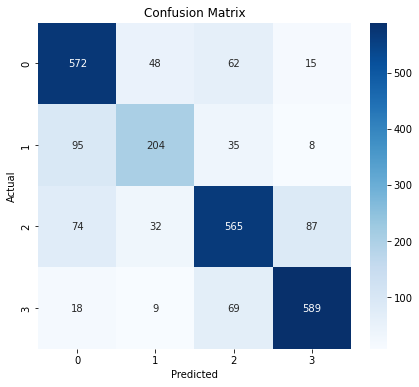

In [128]:
# Checking performance on the testing data
y_pred_test_lgbm = lgbm_model.predict(X_test)

metrics_score(y_test, y_pred_test_lgbm)

In [129]:
fi = pd.DataFrame({
        "feature": lgbm_model.feature_name_,
        "importance": lgbm_model.booster_.feature_importance(importance_type="gain")
    }).sort_values("importance", ascending=False)
print("\nTop features:\n", fi.head(20))


Top features:
             feature    importance
4      powlaw_gamma  58063.186180
2           hard_hs  28067.391594
3           hard_ms  22764.776816
5             bb_kt  17834.634194
1           hard_hm  16077.051901
6        var_prob_b  15005.031468
8        var_prob_h  13709.788664
7       var_ratio_b  12275.392946
9       var_ratio_h  11653.614119
11      var_ratio_s  10001.854466
12       var_newq_b   9005.193780
10       var_prob_s   8397.305120
0   detection_count   1553.100576


#### lightGBM finetuning

In [ ]:
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from lightgbm import LGBMClassifier, early_stopping, log_evaluation

param_dist = {
    "num_leaves": randint(16, 256),
    "max_depth": [-1] + list(range(4, 13)),
    "min_child_samples": randint(5, 100),
    "min_child_weight": uniform(0.0, 0.05),   # 0.0–0.05
    "subsample": uniform(0.6, 0.4),          # 0.6–1.0
    "subsample_freq": randint(1, 7),
    "colsample_bytree": uniform(0.6, 0.4),   # 0.6–1.0
    "reg_lambda": uniform(0.0, 5.0),
    "reg_alpha": uniform(0.0, 2.0),
    "min_split_gain": uniform(0.0, 0.1),
    "learning_rate": uniform(0.02, 0.08),    # 0.02–0.10
}

clf = LGBMClassifier(
    objective="multiclass", n_estimators=5000, n_jobs=-1, random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


search = RandomizedSearchCV(
    estimator=clf,
    param_distributions=param_dist,
    n_iter=60,                    # adjust to your budget
    scoring="f1_macro",           # or "accuracy", "roc_auc_ovr" (binary: "roc_auc")
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True
)

search.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric="multi_logloss",
    callbacks=[early_stopping(100), log_evaluation(100)]
)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003375 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3078
[LightGBM] [Info] Number of data points in the train set: 4632, number of used features: 13
[LightGBM] [Info] Start training from score -1.270624
[LightGBM] [Info] Start training from score -1.979276
[LightGBM] [Info] Start training from score -1.187274
[LightGBM] [Info] Start training from score -1.286910
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

## Summary

This notebook builds and evaluates **tree-based classifiers** for **X-ray source classification** using `out_data/uniquely_classified.csv`.

**Data and setup**
- Loaded the catalog (~8,271 sources, 28 columns), inspected class distribution for `agg_master_class`, and encoded categorical predictors with dummy variables.
- Encoded the target with `LabelEncoder`, dropped identifier and label columns (`name`, `agg_master_class`, `master_class`), and split the data **70% train / 30% test** with stratification.

**Modeling**
- **Decision tree:** Trained with class weights, evaluated on train and test, inspected **feature importance** and a partial **tree visualization** (`max_depth=4`).
- **Random forest:** Baseline fit, then **GridSearchCV** (`scoring='f1_macro'`, 5-fold CV) over criterion, `min_samples_leaf`, and `n_estimators`; best estimator refit on the training split and re-evaluated on the test set.
- **XGBoost:** Configured `XGBClassifier`, evaluated with `metrics_score` and **ROC–AUC** from `predict_proba`; includes PR-curve / average-precision diagnostics in the threshold-related section.
- **LightGBM:** Trained with validation-based fitting (`early_stopping`), reviewed **feature importance**, and ran **RandomizedSearchCV** (60 sampled configs, 5-fold stratified CV, `scoring='f1_macro'`).

**Performance (held-out test set, 2,482 samples)**  
Figures below come from the **classification reports** printed in this notebook (default class decision rule, i.e. argmax of predicted probabilities where applicable).

| Model | Accuracy | Macro F1 | Weighted F1 | Notes |
|--------|----------|----------|-------------|--------|
| Decision tree | 0.68 | 0.66 | 0.68 | Strong overfit on train (~1.0 accuracy). |
| Random forest (before grid search) | 0.762 | 0.734 | 0.756 | Default hyperparameters. |
| Random forest (after `GridSearchCV` + refit) | **0.766** | **0.740** | **0.761** | **Gain vs. pre-tune RF:** +0.004 accuracy (~+0.4 pp), +0.006 macro F1, +0.005 weighted F1. |
| XGBoost | 0.78 (report shows 0.777) | 0.76 (report: 0.759) | 0.78 (0.775) | ROC–AUC **macro 0.940**, **micro 0.945** (from `predict_proba` on the test set). |
| LightGBM (baseline fit in notebook) | 0.78 | 0.76 | 0.78 | Similar headline metrics to XGBoost on this split. |

**Finetuning vs. baseline (what improved, and what is not shown on test yet)**  
- **Random forest:** Hyperparameter search yields a **small but consistent test improvement** over the pre-search forest (accuracy and F1 all move up slightly), aligned with optimizing **macro F1** in CV.  
- **XGBoost:** Hyperparameters in the notebook are fixed; the “threshold” block mainly adds **PR / average-precision** views of the same probabilities (e.g. macro AP ≈ 0.998 on the saved run)—not a separate row of “new” accuracy/F1 unless you explicitly apply tuned thresholds to predictions.  
- **LightGBM:** **RandomizedSearchCV** runs with CV optimized for macro F1, but there is **no follow-up cell** in this notebook that prints test accuracy/F1 for `search.best_estimator_`; to state test improvement after search, evaluate that estimator on `X_test` and compare to the pre-search LightGBM metrics above.

Together, the notebook documents an end-to-end pipeline from **EDA and preprocessing** through **several ensemble tree models**, **interpretability (importances / trees)**, and **hyperparameter search** (RF, LightGBM) plus **probability-based diagnostics** (XGBoost).
